In [3]:
import os
print(os.getcwd())

c:\Users\RAM CHOUDHARY\Desktop\Python\late-delivery-risk\notebooks


In [5]:
import os
print(os.path.exists('late-delivery-risk/data/processed/model_ready.csv'))

False


In [6]:
import os
print(os.getcwd())
print(os.listdir())

c:\Users\RAM CHOUDHARY\Desktop\Python\late-delivery-risk\notebooks
['03_model.ipynb']


In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
import joblib

df = pd.read_csv('../data/processed/model_ready.csv')

X = df.drop(columns=['is_late'])
y = df['is_late']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(
    n_estimators=200, max_depth=10, class_weight='balanced', random_state=42
)
model.fit(X_train, y_train)

print("Training complete")

Training complete


In [8]:
y_pred = model.predict(X_test)
y_proba=model.predict_proba(X_test)[:,1]
print(classification_report(y_test,y_pred))
print("ROC-AUC:",roc_auc_score(y_test,y_proba))

              precision    recall  f1-score   support

           0       0.62      0.84      0.71     16308
           1       0.81      0.58      0.68     19796

    accuracy                           0.70     36104
   macro avg       0.72      0.71      0.69     36104
weighted avg       0.73      0.70      0.69     36104

ROC-AUC: 0.7314386884807325


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

In [ ]:
joblib.dump(model,'../models/late_delivery_model.pkl')
print("Model saved")

Model saved


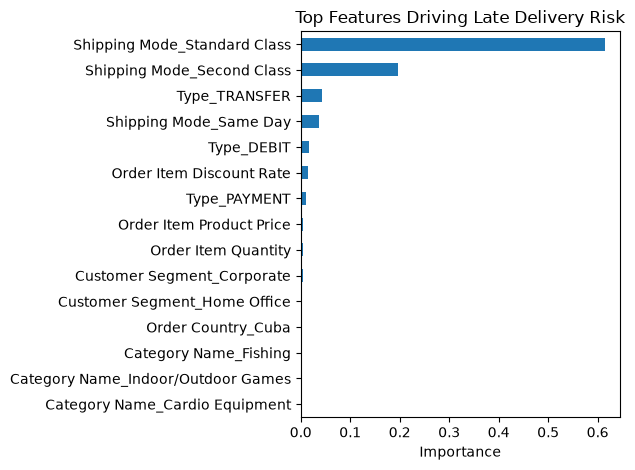

Shipping Mode_Standard Class          0.614432
Shipping Mode_Second Class            0.195922
Type_TRANSFER                         0.043645
Shipping Mode_Same Day                0.037326
Type_DEBIT                            0.016579
Order Item Discount Rate              0.014071
Type_PAYMENT                          0.010890
Order Item Product Price              0.005383
Order Item Quantity                   0.004646
Customer Segment_Corporate            0.004002
Customer Segment_Home Office          0.003277
Order Country_Cuba                    0.001123
Category Name_Fishing                 0.001032
Category Name_Indoor/Outdoor Games    0.000984
Category Name_Cardio Equipment        0.000937
dtype: float64


In [ ]:
import matplotlib.pyplot as plt

importances = pd.Series(model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(15)

top_features.plot(kind='barh')
plt.title('Top Features Driving Late Delivery Risk')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../data/processed/feature_importance.png')
plt.show()

print(top_features)

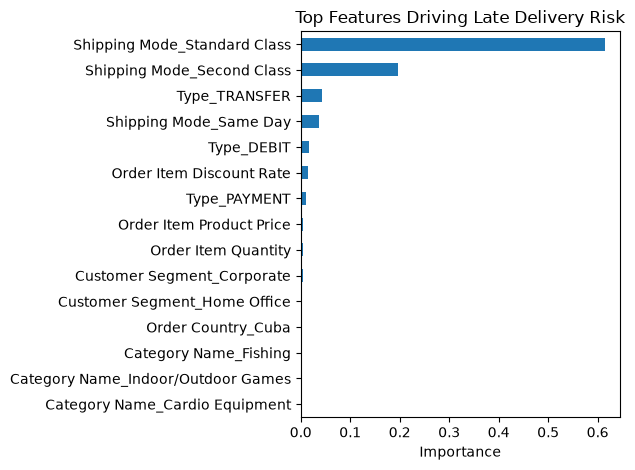

Shipping Mode_Standard Class          0.614432
Shipping Mode_Second Class            0.195922
Type_TRANSFER                         0.043645
Shipping Mode_Same Day                0.037326
Type_DEBIT                            0.016579
Order Item Discount Rate              0.014071
Type_PAYMENT                          0.010890
Order Item Product Price              0.005383
Order Item Quantity                   0.004646
Customer Segment_Corporate            0.004002
Customer Segment_Home Office          0.003277
Order Country_Cuba                    0.001123
Category Name_Fishing                 0.001032
Category Name_Indoor/Outdoor Games    0.000984
Category Name_Cardio Equipment        0.000937
dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

importances = pd.Series(model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(15)

top_features.plot(kind='barh')
plt.title('Top Features Driving Late Delivery Risk')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../data/processed/feature_importance.png')
plt.show()

print(top_features)

In [ ]:
full_proba = model.predict_proba(X)[:,1]
cleaned = pd.read_csv('../data/processed/cleaned.csv')
cleaned=cleaned.loc[X.index].reset_index(drop=True)
cleaned['late_risk_score']=full_proba
cleaned['risk_tier']=pd.cut(full_proba,bins=[0,0.33,0.66,1],labels=['Low','Medium','High'])

cleaned.to_csv('../data/processed/scored_orders.csv',index=False)
print("Scored file saved:",cleaned.shape)

Scored file saved: (180516, 48)


In [ ]:
import sqlite3

conn = sqlite3.connect('../data/processed/supply_chain.db')
cleaned.to_sql('scored_orders', conn, if_exists='replace', index=False)
print("Database built")

Database built


In [ ]:
# High-risk order backlog by market and shipping mode
query1 = """
SELECT Market, "Shipping Mode", COUNT(*) as high_risk_orders
FROM scored_orders
WHERE risk_tier = 'High'
GROUP BY Market, "Shipping Mode"
ORDER BY high_risk_orders DESC
LIMIT 10
"""
print(pd.read_sql(query1, conn))

         Market Shipping Mode  high_risk_orders
0        Europe  Second Class              7247
1         LATAM  Second Class              7111
2  Pacific Asia  Second Class              6062
3        Europe   First Class              5309
4         LATAM   First Class              4548
5          USCA  Second Class              3740
6  Pacific Asia   First Class              3694
7          USCA   First Class              2535
8        Africa  Second Class              1604
9        Africa   First Class              1060


In [ ]:
# Average risk score by market
query2 = """
SELECT Market, AVG(late_risk_score) as avg_risk
FROM scored_orders
GROUP BY Market
ORDER BY avg_risk DESC
"""
print(pd.read_sql(query2, conn))

         Market  avg_risk
0        Europe  0.509390
1  Pacific Asia  0.506738
2          USCA  0.506045
3        Africa  0.503197
4         LATAM  0.501828


In [ ]:
query3 = """
SELECT risk_tier, AVG(Late_delivery_risk) as actual_late_rate, COUNT(*) as n
FROM scored_orders
GROUP BY risk_tier
"""
print(pd.read_sql(query3, conn))

  risk_tier  actual_late_rate       n
0      High          0.879585   42910
1       Low          0.000000       3
2    Medium          0.444998  137603


In [ ]:
print(pd.read_sql("PRAGMA table_info(scored_orders)",conn))

    cid                           name     type  notnull dflt_value  pk
0     0                           Type     TEXT        0       None   0
1     1       Days for shipping (real)  INTEGER        0       None   0
2     2  Days for shipment (scheduled)  INTEGER        0       None   0
3     3              Benefit per order     REAL        0       None   0
4     4             Sales per customer     REAL        0       None   0
5     5                Delivery Status     TEXT        0       None   0
6     6             Late_delivery_risk  INTEGER        0       None   0
7     7                    Category Id  INTEGER        0       None   0
8     8                  Category Name     TEXT        0       None   0
9     9                  Customer City     TEXT        0       None   0
10   10               Customer Country     TEXT        0       None   0
11   11                    Customer Id  INTEGER        0       None   0
12   12               Customer Segment     TEXT        0       N